<a href="https://colab.research.google.com/github/amairagoel/Statistical-Arbitrage-Walk-Forward-Pairs-Trading-Engine/blob/main/Statistical_Arbitrage_Walk_Forward_Pairs_Trading_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Downloading Basket Data...
2. Running Walk-Forward Optimization (Dynamic Pair Rotation)...

--- Optimizing for Trading Year: 2021 ---
Selected Pair: SBIN.NS & AXISBANK.NS (In-Sample p-value: 0.0062)

--- Optimizing for Trading Year: 2022 ---
Selected Pair: ICICIBANK.NS & SBIN.NS (In-Sample p-value: 0.0030)

--- Optimizing for Trading Year: 2023 ---
Selected Pair: KOTAKBANK.NS & INDUSINDBK.NS (In-Sample p-value: 0.0116)

=== FINAL OUT-OF-SAMPLE RESULTS (Walk-Forward 2021-2023) ===
Annualised Return: 27.25%
Annualised Volatility: 24.54%
Sharpe Ratio: 1.11


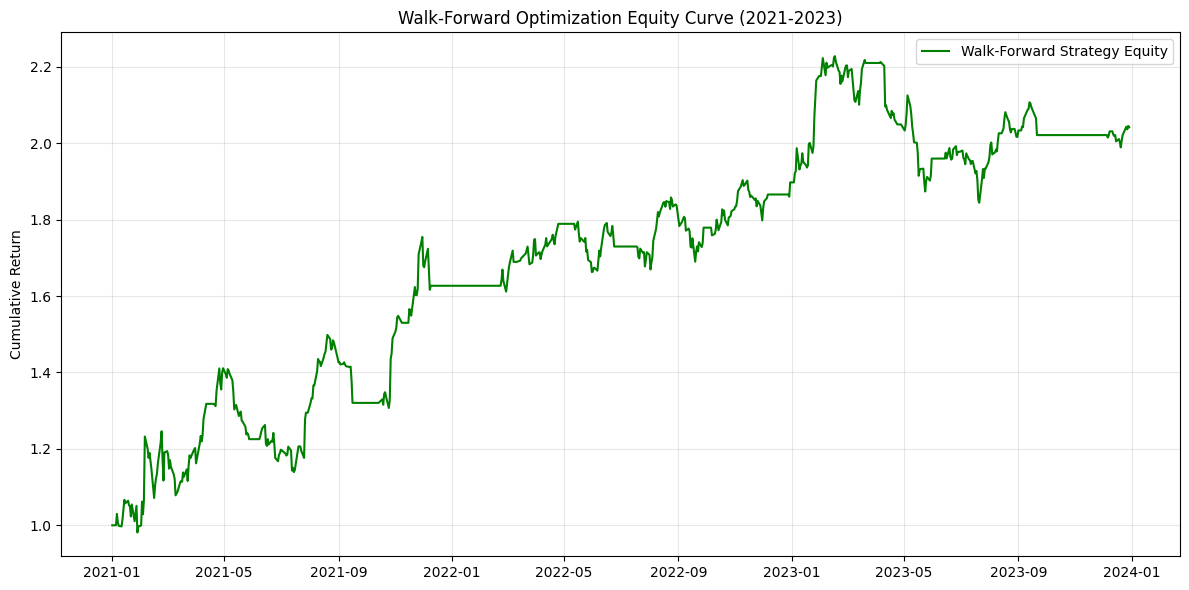

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
import itertools
import warnings

# Suppress statsmodels warnings for clean output
warnings.filterwarnings("ignore")

print("1. Downloading Basket Data...")
tickers = ['HDFCBANK.NS', 'ICICIBANK.NS', 'SBIN.NS', 'KOTAKBANK.NS', 'AXISBANK.NS', 'INDUSINDBK.NS']
data = yf.download(tickers, start='2018-01-01', end='2024-01-01', auto_adjust=False, progress=False)['Close']
data.dropna(inplace=True)

# Apply log transform to stabilize variance
log_data = np.log(data)

print("2. Running Walk-Forward Optimization (Dynamic Pair Rotation)...")
out_of_sample_returns = []
historical_pairs = []

# We will trade 2021, 2022, and 2023.
trading_years = [2021, 2022, 2023]

for trade_year in trading_years:
    print(f"\n--- Optimizing for Trading Year: {trade_year} ---")

    # 1. Train Window (Lookback 2 years)
    train_start = str(trade_year - 2)
    train_end = str(trade_year - 1)
    train_data = log_data.loc[f'{train_start}-01-01':f'{train_end}-12-31']

    # 2. Screener: Find the best pair for the upcoming year
    best_pair = None
    lowest_p_value = 1.0

    for pair in itertools.combinations(tickers, 2):
        # Run cointegration test
        score, p_value, _ = coint(train_data[pair[0]], train_data[pair[1]])

        if p_value < lowest_p_value:
            lowest_p_value = p_value
            best_pair = pair

    print(f"Selected Pair: {best_pair[0]} & {best_pair[1]} (In-Sample p-value: {lowest_p_value:.4f})")
    historical_pairs.append((trade_year, best_pair))

    # 3. Trade Window: Prepare data
    # We pull a 6-month buffer prior to the trade year to calculate our rolling metrics
    buffer_start = str(trade_year - 1) + "-07-01"
    trade_end = str(trade_year) + "-12-31"
    raw_trade_data = log_data.loc[buffer_start:trade_end].copy()

    y = raw_trade_data[best_pair[0]]
    x = raw_trade_data[best_pair[1]]
    trade_data = pd.DataFrame(index=raw_trade_data.index)

    # 4. Calculate Dynamic Hedge Ratio
    beta_lookback = 60
    rolling_cov = y.rolling(window=beta_lookback).cov(x)
    rolling_var = x.rolling(window=beta_lookback).var()

    trade_data['beta'] = (rolling_cov / rolling_var).shift(1)
    trade_data['spread'] = y - (trade_data['beta'] * x)

    # 5. Calculate Z-Score
    z_lookback = 30
    trade_data['spread_mean'] = trade_data['spread'].rolling(z_lookback).mean().shift(1)
    trade_data['spread_std'] = trade_data['spread'].rolling(z_lookback).std().shift(1)
    trade_data['z_score'] = (trade_data['spread'] - trade_data['spread_mean']) / trade_data['spread_std']

    # Isolate JUST the actual trading year (drop the 6-month buffer)
    trade_data = trade_data.loc[f'{trade_year}-01-01':f'{trade_year}-12-31'].copy()
    y_trade = data[best_pair[0]].loc[f'{trade_year}-01-01':f'{trade_year}-12-31']
    x_trade = data[best_pair[1]].loc[f'{trade_year}-01-01':f'{trade_year}-12-31']

    # 6. Generate Signals
    entry_threshold = 2.0
    stop_loss = 3.5

    z_scores = trade_data['z_score'].values
    positions = np.zeros(len(trade_data))

    for i in range(1, len(trade_data)):
        prev_pos = positions[i-1]
        z = z_scores[i]

        if np.isnan(z): continue

        if prev_pos == 0:
            if z < -entry_threshold: positions[i] = 1
            elif z > entry_threshold: positions[i] = -1
        elif prev_pos == 1:
            if z > -0.5 or z < -stop_loss: positions[i] = 0
            else: positions[i] = 1
        elif prev_pos == -1:
            if z < 0.5 or z > stop_loss: positions[i] = 0
            else: positions[i] = -1

    trade_data['position'] = positions

    # 7. Calculate Returns for this year
    trade_data['y_ret'] = y_trade.pct_change()
    trade_data['x_ret'] = x_trade.pct_change()

    trade_data['spread_ret'] = trade_data['y_ret'] - (trade_data['beta'] * trade_data['x_ret'])
    trade_data['strategy_return'] = trade_data['position'].shift(1) * trade_data['spread_ret']

    out_of_sample_returns.append(trade_data['strategy_return'])

# 8. Stitch it all together and evaluate
print("\n=== FINAL OUT-OF-SAMPLE RESULTS (Walk-Forward 2021-2023) ===")
# Combine all the yearly returns into one continuous equity curve
final_returns = pd.concat(out_of_sample_returns).fillna(0)
cumulative_return = (1 + final_returns).cumprod()

ann_return = final_returns.mean() * 252
ann_vol = final_returns.std() * np.sqrt(252)
sharpe = ann_return / ann_vol if ann_vol != 0 else 0

print(f"Annualised Return: {ann_return:.2%}")
print(f"Annualised Volatility: {ann_vol:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")

# 9. Plot the Continuous Walk-Forward Equity Curve
plt.figure(figsize=(12, 6))
plt.plot(final_returns.index, cumulative_return, color='green', label='Walk-Forward Strategy Equity')
plt.title(f"Walk-Forward Optimization Equity Curve (2021-2023)")
plt.ylabel('Cumulative Return')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()